# 위플래닛 중고 기기 매입가 산정 모델 — 최종 통합본

**실행 순서: 위에서 아래로 순서대로 실행**

## 전체 구조
```
1단계: 전처리
2단계: EDA
3단계: XGBoost 기준가 예측
4단계: 차감 로직 (정률 + 정액)
5단계: 성능 평가 + 마진 분석
6단계: 모델 저장
```

## 전처리 기준
```
1차 (팀 공통): productId 결측 제거 / paid만 / 기타 제거 /
               부품용 키워드 제거 / 매입가 0·결측 제거 / 5만원 미만 제거
2차 (추가):    맥북 20만원 미만 제거 / 아이패드·아이폰 15만원 미만 제거 /
               경과월 60개월 초과 제거
```

---
## 0. 패키지 설치

In [ ]:
!pip install xgboost statsmodels -q

---
## 1. 라이브러리 및 파일명 설정
> ★ 파일명 여기서만 변경하세요 ★

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, json, warnings
import joblib
import platform

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from scipy.optimize import curve_fit
import xgboost as xgb

warnings.filterwarnings('ignore')

# 한글 폰트
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# ★ 파일명 여기서만 변경하세요 ★
# ============================================================
STOCK_FILE     = '1.매입상품(stock)_v2.1.csv'
SALES_FILE     = '2.판매상품(goods).csv'
INSPECT_FILE3  = '데이터 부트캠프 - 3.상품 점검 목록(inspection).xlsx'
INSPECT_FILE4  = '데이터 부트캠프 - 4.상품 점검 하위 옵션(inspectionOption).xlsx'
INSPECT_FILE5  = '데이터 부트캠프 - 5.매입 상품 점검 목록(inspection_stock).xlsx'
# ============================================================

print("✅ 라이브러리 로드 완료")
print(f"   매입파일: {STOCK_FILE}")

✅ 라이브러리 로드 완료
   매입파일: 1.매입상품(stock)_v2.1.csv


---
## 2. 데이터 로드 및 전처리

In [3]:
# ── 원본 로딩 ──
df = pd.read_csv(STOCK_FILE, encoding='utf-8-sig')
print(f"원본: {df.shape}")

# 숫자 변환
df['매입가'] = pd.to_numeric(df['매입가'].astype(str).str.replace(',','').str.strip(), errors='coerce')
df['출시가'] = pd.to_numeric(df['출시가'].astype(str).str.replace(',','').str.strip(), errors='coerce')
df['매입일'] = pd.to_datetime(df['매입일'], errors='coerce')
df['출시일'] = pd.to_datetime(df['출시일'], errors='coerce')

before = len(df)

# ── 1. productId 결측치 제거 ──
df = df[df['productId'].notna()].copy()
print(f"1. productId 결측 제거: -{before - len(df)}건")
before = len(df)

# ── 2. status: paid만 ──
df = df[df['status'] == 'paid'].copy()
print(f"2. paid만:              -{before - len(df)}건")
before = len(df)

# ── 3. 분류: 기타 제거 ──
df = df[df['분류'].isin(['맥북','아이패드','아이폰'])].copy()
print(f"3. 기타 제거:           -{before - len(df)}건")
before = len(df)

# ── 4. overall: 부품용 키워드 제거 ──
부품_키워드 = ['부품용','부품가','부품매입','부품매각','액정부품','부품으로']
부품_mask = df['orverall'].astype(str).str.contains('|'.join(부품_키워드), na=False)
df = df[~부품_mask].copy()
print(f"4. 부품용 키워드 제거:  -{before - len(df)}건")
before = len(df)

# ── 5. id 보존 (차감 로직 연동용) ──
df = df.reset_index(drop=True)
df_id_map = df[['id']].copy()
df_id_map['id_str'] = df_id_map['id'].astype(str)

# ── 6. 매입가 0원/결측치 제거 ──
df = df[(df['매입가'] > 0) & (df['매입가'].notna())].copy()
print(f"6. 매입가 0/결측 제거:  -{before - len(df)}건")
before = len(df)

# ── 7. 매입가 5만원 미만 제거 ──
df = df[df['매입가'] >= 50000].copy()
print(f"7. 5만원 미만 제거:     -{before - len(df)}건")
before = len(df)

# ── 8. 경과월 계산 ──
df = df[df['출시일'].notna()].copy()
df['Age_month'] = (df['매입일'] - df['출시일']).dt.days / 30.44
df['매입연도']  = df['매입일'].dt.year

# ── 9. 잔존가치/이상치 제거 ──
df['잔존가치'] = df['매입가'] / df['출시가']
before = len(df)
df = df[(df['잔존가치'] <= 1.0) & (df['Age_month'] > 0)].copy()
print(f"9. 잔존가치 이상치:     -{before - len(df)}건")
before = len(df)

# ── 10. 2차 전처리 (추가 기준) ──
df = df[
    (df['Age_month'] <= 60) &
    (
        ((df['분류']=='맥북')    & (df['매입가'] >= 200000)) |
        ((df['분류']=='아이패드') & (df['매입가'] >= 150000)) |
        ((df['분류']=='아이폰')  & (df['매입가'] >= 150000))
    )
].copy()
print(f"10. 2차전처리 (60개월/하한가): -{before - len(df)}건")

# id_str 붙이기
df = df.reset_index(drop=True)
df['id_str'] = df['id'].astype(str)

print(f"\n✅ 최종 데이터: {len(df)}행")
print(f"분류 분포:\n{df['분류'].value_counts()}")
print(f"\n잔존가치 기초통계:\n{df['잔존가치'].describe().round(3)}")

원본: (2159, 10)
1. productId 결측 제거: -0건
2. paid만:              -0건
3. 기타 제거:           -0건
4. 부품용 키워드 제거:  -68건
6. 매입가 0/결측 제거:  -0건
7. 5만원 미만 제거:     -23건
9. 잔존가치 이상치:     -0건
10. 2차전처리 (60개월/하한가): -467건

✅ 최종 데이터: 1601행
분류 분포:
분류
맥북      1207
아이패드     337
아이폰       57
Name: count, dtype: int64

잔존가치 기초통계:
count    1601.000
mean        0.408
std         0.149
min         0.063
25%         0.297
50%         0.409
75%         0.519
max         0.935
Name: 잔존가치, dtype: float64


---
## 3. EDA (탐색적 데이터 분석)

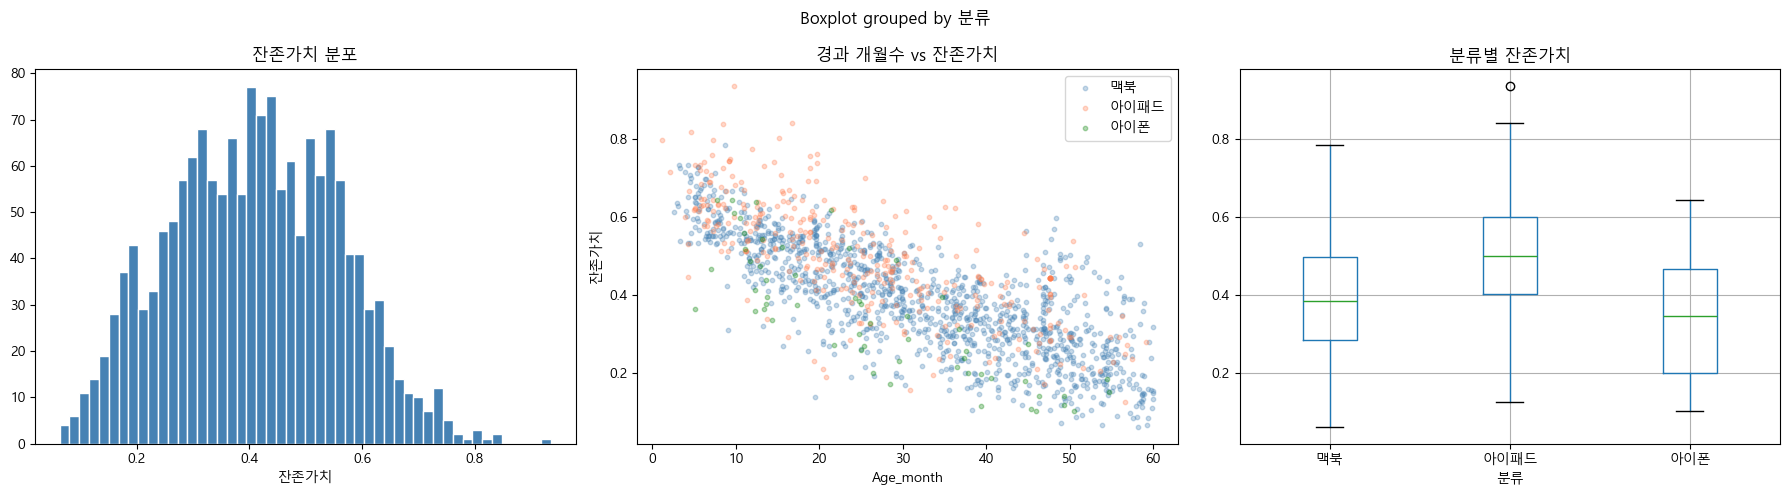

=== 카테고리별 지수 감가율 ===
분류               월감가율       연감가율      3년후잔존
--------------------------------------------
맥북              1.89%      20.3%      34.5%
아이패드            1.58%      17.3%      41.2%
아이폰             2.85%      28.9%      24.5%


In [4]:
# 잔존가치 분포 및 감가 곡선 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. 잔존가치 분포
axes[0].hist(df['잔존가치'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('잔존가치 분포')
axes[0].set_xlabel('잔존가치')

# 2. Age_month vs 잔존가치 (카테고리별)
for cat, color in zip(['맥북','아이패드','아이폰'], ['steelblue','coral','green']):
    subset = df[df['분류'] == cat]
    axes[1].scatter(subset['Age_month'], subset['잔존가치'],
                    alpha=0.3, label=cat, color=color, s=10)
axes[1].set_title('경과 개월수 vs 잔존가치')
axes[1].set_xlabel('Age_month')
axes[1].set_ylabel('잔존가치')
axes[1].legend()

# 3. 분류별 박스플롯
df.boxplot(column='잔존가치', by='분류', ax=axes[2])
axes[2].set_title('분류별 잔존가치')

plt.tight_layout()
plt.show()

# 카테고리별 지수 감가율 산출
def exp_func(x, a, k): return a * np.exp(-k * x)

print("=== 카테고리별 지수 감가율 ===")
print(f"{'분류':<10} {'월감가율':>10} {'연감가율':>10} {'3년후잔존':>10}")
print("-" * 44)
for cat in ['맥북','아이패드','아이폰']:
    sub = df[df['분류']==cat]
    try:
        popt, _ = curve_fit(exp_func, sub['Age_month'].values,
                            sub['잔존가치'].values, p0=[1, 0.02])
        print(f"{cat:<10} {popt[1]*100:>9.2f}% "
              f"{(1-np.exp(-popt[1]*12))*100:>9.1f}% "
              f"{exp_func(36,*popt)*100:>9.1f}%")
    except:
        print(f"{cat:<10} 피팅 실패")

---
## 4. 예측 모델 학습 (XGBoost)

In [5]:
# 피처 엔지니어링
df['품명'] = df['품명'].str.replace(',','').str.strip()

le_cat   = LabelEncoder()
le_brand = LabelEncoder()
df['분류_enc'] = le_cat.fit_transform(df['분류'])
df['품명_enc'] = le_brand.fit_transform(df['품명'])
df['price_tier'] = pd.cut(df['출시가'],
    bins=[0, 1000000, 1500000, 2000000, 2500000, 99999999],
    labels=[1, 2, 3, 4, 5]).astype(int)

# 피처 / 타겟 분리
features = ['Age_month', '분류_enc', '품명_enc', '출시가', 'price_tier', '매입연도']
X = df[features]
y = df['잔존가치']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# XGBoost 학습
model = xgb.XGBRegressor(
    subsample=0.8, n_estimators=300, min_child_weight=1,
    max_depth=6, learning_rate=0.03, colsample_bytree=0.8,
    random_state=42)
model.fit(X_train, y_train)

# 성능 평가
y_pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
r2   = r2_score(y_test, y_pred)
w10  = (np.abs((y_pred - y_test) / y_test) <= 0.1).mean() * 100
w20  = (np.abs((y_pred - y_test) / y_test) <= 0.2).mean() * 100

print("=== 입력 피처 ===")
for i, f in enumerate(features, 1):
    print(f"  {i}. {f}")

print(f"\n=== 최종 모델 성능 ===")
print(f"R²    : {r2*100:.1f}%")
print(f"MAE   : {mae*100:.1f}%")
print(f"MAPE  : {mape:.1f}%")
print(f"±10%  : {w10:.1f}%")
print(f"±20%  : {w20:.1f}%")
print(f"데이터 : {len(df)}행 (학습 {len(X_train)} / 테스트 {len(X_test)})")

=== 입력 피처 ===
  1. Age_month
  2. 분류_enc
  3. 품명_enc
  4. 출시가
  5. price_tier
  6. 매입연도

=== 최종 모델 성능 ===
R²    : 79.8%
MAE   : 4.7%
MAPE  : 13.9%
±10%  : 54.8%
±20%  : 79.1%
데이터 : 1601행 (학습 1280 / 테스트 321)


In [ ]:
# 모델 비교 (선형/다항회귀 vs XGBoost)
print("=== 모델별 성능 비교 ===")
print(f"{'모델':<15} {'MAE':>7} {'MAPE':>7} {'R²':>7} {'±10%':>7} {'±20%':>7}")
print("-" * 55)

model_results = {}
lr = LinearRegression().fit(X_train, y_train)
model_results['선형회귀'] = lr.predict(X_test)

for degree in [2, 3]:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('ridge', Ridge(alpha=1.0))])
    pipe.fit(X_train, y_train)
    model_results[f'다항회귀({degree}차)'] = pipe.predict(X_test)

model_results['XGBoost'] = y_pred

for name, pred in model_results.items():
    m  = mean_absolute_error(y_test, pred)*100
    mp = mean_absolute_percentage_error(y_test, pred)*100
    r  = r2_score(y_test, pred)*100
    w1 = (np.abs((pred-y_test)/y_test)<=0.1).mean()*100
    w2 = (np.abs((pred-y_test)/y_test)<=0.2).mean()*100
    print(f"{name:<15} {m:>6.1f}% {mp:>6.1f}% {r:>6.1f}% {w1:>6.1f}% {w2:>6.1f}%")

# 피처 중요도
fig, ax = plt.subplots(figsize=(10, 5))
xgb.plot_importance(model, max_num_features=10, ax=ax, importance_type='gain')
ax.set_title('피처 중요도 (gain 기준)')
plt.tight_layout()
plt.show()

---
## 4-1. XGBoost 전체 데이터 기준가 예측

In [6]:
# 전체 df에 XGBoost 예측값 적용 (차감 로직 연동)
df['xgb_잔존율'] = model.predict(df[features])
df['xgb_기준가'] = df['xgb_잔존율'] * df['출시가']
df['잔차']       = df['잔존가치'] - df['xgb_잔존율']

print(f"✅ XGBoost 기준가 계산 완료: {len(df)}건")
print(f"\n기준가 분포:")
print((df['xgb_기준가']/10000).describe().round(1))

✅ XGBoost 기준가 계산 완료: 1601건

기준가 분포:
count    1601.0
mean       83.9
std        45.5
min        15.0
25%        47.9
50%        75.7
75%       107.5
max       260.6
Name: xgb_기준가, dtype: float64


---
## 5. 점검 파일 로딩 (3/4/5번)

In [8]:
# ── 3번: 검수 항목 목록 ──
df3 = pd.read_excel(INSPECT_FILE3, sheet_name='상품 점검 목록(Inspections)')
df3.columns = ['insp_id','insp_key','insp_name']
df3 = df3[df3['insp_id'].notna()].copy()
df3['insp_id'] = pd.to_numeric(df3['insp_id'], errors='coerce')

# ── 4번: 검수 옵션 목록 ──
df4 = pd.read_excel(INSPECT_FILE4, sheet_name='상품 점검 하위 옵션(InspectionOptions)')
df4.columns = ['opt_id','opt_name','opt_price','insp_id','opt_status']
df4 = df4[df4['opt_id'].notna()].copy()
df4['opt_id']  = pd.to_numeric(df4['opt_id'],  errors='coerce')
df4['insp_id'] = pd.to_numeric(df4['insp_id'], errors='coerce')

# 3/4번 조인
df_opt = df4.merge(df3[['insp_id','insp_name']], on='insp_id', how='left')

# ── 5번: 실제 점검 결과 ──
df5_all = pd.read_excel(INSPECT_FILE5, sheet_name=None)
sheet_name = list(df5_all.keys())[1]
df5 = df5_all[sheet_name].copy()
df5['final_optionId'] = df5['optionId'].fillna(df5['userOptionId'])
df5['stockId_str']    = df5['stockId'].astype(str)

# 5번 + 3/4번 조인
df_merged = df5.merge(
    df_opt[['opt_id','insp_name','opt_name']],
    left_on='final_optionId', right_on='opt_id', how='left'
)

# 분석 대상만 필터
target_ids = set(df['id_str'])
df_target = df_merged[df_merged['stockId_str'].isin(target_ids)].copy()

print(f"✅ 점검 파일 로딩 완료")
print(f"   분석 대상 점검 레코드: {len(df_target)}건")
print(f"   커버 상품 수: {df_target['stockId_str'].nunique()}건")

✅ 점검 파일 로딩 완료
   분석 대상 점검 레코드: 13700건
   커버 상품 수: 1601건


---
## 6. 정률표 + 정액표 최종 확정
> 수치 수정 시 여기만 변경하고 이후 셀 재실행

In [9]:
# ────────────────────────────────────────────────
# 정률표 (XGBoost 잔차 기반 — 최종 확정)
# 기준: 없음/정상/1~50 = 0%
# 아이패드/아이폰: 맥북 준용
# ────────────────────────────────────────────────
정률표 = {
    '생활 기스': {
        '없음':  0.0,
        '약간': -0.0094,   # -0.94% ✅ n=332
        '심각': -0.0354,   # -3.54% ⚠️ n=17
    },
    '찍힘/깨짐': {
        # 약간 = 찍힘 약간 / 심각 = 찍힘 심각 / 깨짐 = 담당자 문의
        '없음':  0.0,
        '약간': -0.0182,   # -1.82% ✅ n=242
        '심각': -0.0450,   # -4.50% ❌ n=9
    },
    '액정 상태': {
        '정상':              0.0,
        '불량 화소':         -0.0247,   # -2.47% ⚠️ n=29
        '코팅 벗겨짐':       -0.0399,   # -3.99% ❌ n=4
        '깨짐(담당자 문의)': -0.1386,   # -13.86% ❌ n=8
    },
    '배터리 사이클': {
        '1~50':    0.0,
        '50~100':  -0.0074,   # -0.74% ✅ n=107
        '100~200': -0.0139,   # -1.39% ✅ n=147
        '200~500': -0.0253,   # -2.53% ✅ n=173
        '500 이상': -0.0480,  # -4.80% ⚠️ n=21
    }
}

# ────────────────────────────────────────────────
# 정액표 (팀 확정 기준 — 분류별)
# ────────────────────────────────────────────────

# 맥북 전용
정액표_맥북 = {
    '해외구매_영문자판':  -50000,   # 영문자판 외 → 매입불가
    '힌지_흔들림':       -30000,   # 고정불가 → 담당자 문의
    '업그레이드_RAM':     50000,
    '업그레이드_CPU':     50000,
    '업그레이드_SSD':     50000,
    '박스있음':            5000,
    '애플케어_월':         5000,   # 잔여개월 × 5,000원
}

# 아이패드 전용
정액표_아이패드 = {
    # 해외구매: 무차감
    '박스있음':    5000,
    '애플케어_월':  5000,
}

# 아이폰 전용
정액표_아이폰 = {
    # 미국판: 매입불가 / 그외 해외판: 무차감
    '박스있음':    5000,
    '애플케어_월':  5000,
}

# 공통 악세서리
악세_정액 = {
    '맥북용키보드':       50000,
    '아이패드용키보드':    80000,
    '매직마우스':         30000,
    '애플펜슬1':          40000,
    '애플펜슬2':          70000,
    '케이블':              5000,
    '어댑터_맥북':        25000,
    '어댑터_아이폰패드':  10000,
}

print("✅ 정률표 + 정액표 설정 완료")
print("\n[정률표]")
for 항목, 옵션들 in 정률표.items():
    print(f"  [{항목}]")
    for 옵션, 율 in 옵션들.items():
        print(f"    {옵션}: {율:+.2%}")

✅ 정률표 + 정액표 설정 완료

[정률표]
  [생활 기스]
    없음: +0.00%
    약간: -0.94%
    심각: -3.54%
  [찍힘/깨짐]
    없음: +0.00%
    약간: -1.82%
    심각: -4.50%
  [액정 상태]
    정상: +0.00%
    불량 화소: -2.47%
    코팅 벗겨짐: -3.99%
    깨짐(담당자 문의): -13.86%
  [배터리 사이클]
    1~50: +0.00%
    50~100: -0.74%
    100~200: -1.39%
    200~500: -2.53%
    500 이상: -4.80%


---
## 7. 차감 로직 함수 정의

In [10]:
def 차감로직_계산(stock_id, xgb_기준가, 출시가, 분류, verbose=True):
    """
    최종 매입가 산출 함수

    Parameters:
        stock_id   : 매입상품 id
        xgb_기준가  : XGBoost 예측 잔존율 × 출시가
        출시가      : 출시 당시 공식 가격
        분류        : '맥북' / '아이패드' / '아이폰'
        verbose    : True면 계산 과정 출력

    Returns:
        dict: xgb_기준가, 정률차감, 정액조정, 최종예측가, 검수필요
    """
    stock_id = str(stock_id)
    insp = df_target[df_target['stockId_str'] == stock_id].copy()

    # 분류별 정액표 선택
    if 분류 == '맥북':      정액표 = 정액표_맥북
    elif 분류 == '아이패드': 정액표 = 정액표_아이패드
    else:                   정액표 = 정액표_아이폰

    # ── 정률 차감 ──
    정률합계 = 0.0
    정률내역 = []
    검수필요  = []   # ← 담당자문의 → 검수필요로 변경

    for 항목, 옵션_dict in 정률표.items():
        행 = insp[insp['insp_name'] == 항목]
        if len(행) == 0: continue
        옵션 = 행.iloc[0]['opt_name']
        율 = 옵션_dict.get(옵션, 0.0)
        금액 = xgb_기준가 * 율
        정률합계 += 금액
        정률내역.append((항목, 옵션, 율, 금액))

    # ── 정액 차감/추가 ──
    정액합계 = 0
    정액내역 = []

    for _, row in insp.iterrows():
        항목 = row['insp_name']
        옵션 = row['opt_name']
        금액 = 0
        메모 = ''

        # 구매 경로
        if 항목 == '구매 경로':
            if 옵션 == '국외':
                if 분류 == '맥북':
                    검수필요.append('해외구매 → 영문자판 확인 필요 (영문자판: -50,000원 / 그외: 매입불가)')
                elif 분류 == '아이폰':
                    검수필요.append('해외구매 → 미국판 여부 확인 필요 (미국판: 매입불가 / 그외: 무차감)')

        # 힌지 (맥북 전용)
        elif 항목 == '힌지 고정 상태' and 분류 == '맥북':
            if '흔들림' in str(옵션):
                금액 = 정액표_맥북['힌지_흔들림']; 메모 = '힌지 흔들림 -30,000원'
            elif '고정불가' in str(옵션):
                검수필요.append('힌지 고정불가 → 검수 필요')

        # 업그레이드 (맥북 전용)
        elif 항목 == '업그레이드' and 분류 == '맥북':
            if 옵션 == 'RAM':       금액 = 정액표_맥북['업그레이드_RAM']; 메모 = 'RAM +50,000원'
            elif 옵션 == 'CPU':     금액 = 정액표_맥북['업그레이드_CPU']; 메모 = 'CPU +50,000원'
            elif 옵션 == 'SSD/HDD': 금액 = 정액표_맥북['업그레이드_SSD']; 메모 = 'SSD +50,000원'

        # 박스 유무
        elif 항목 == '제품 박스 유무':
            if 옵션 == '있음':
                금액 = 정액표.get('박스있음', 0); 메모 = '박스있음 +5,000원'

        # 애플케어 ← 수정: 잔여개월 6개월 미만 미적용 기준 추가
        elif 항목 == '애플 보증(케어플러스)':
            if '유효' in str(옵션):
                검수필요.append(
                    '애플케어 유효 → 잔여개월 확인 필요\n'                    '  · 맥북: 최대 3년 기준 (잔여개월 × 5,000원)\n'                    '  · 아이패드: 최대 2년 기준 (잔여개월 × 5,000원)\n'                    '  · 잔여개월 6개월 미만: 미적용 (0원)'
                )

        # 작동 여부
        elif 항목 == '작동 여부':
            if 옵션 not in ['모두 정상','정상']:
                검수필요.append(f'작동이상: {옵션} → 검수 필요')

        # 카메라 상태 ← 수정: 전부 검수 필요
        elif 항목 == '카메라 상태':
            if 옵션 not in ['정상','모두 정상']:
                검수필요.append(f'카메라이상: {옵션} → 검수 필요')

        # 깨짐
        elif 항목 == '찍힘/깨짐' and '깨짐' in str(옵션):
            검수필요.append('깨짐 → 검수 필요')

        # LCD 손상
        elif 항목 == '액정 상태' and 'LCD' in str(옵션):
            검수필요.append('LCD 손상 → 검수 필요')

        # 악세서리
        elif 항목 == '함께 판매할 악세서리':
            악세_map = {
                '애플매직키보드2':          악세_정액['맥북용키보드'],
                '애플스마트키보드(아이패드)': 악세_정액['아이패드용키보드'],
                '매직마우스1':              악세_정액['매직마우스'],
                '매직마우스2(케이블포함)':   악세_정액['매직마우스'],
                '애플펜슬':                 악세_정액['애플펜슬1'],
                '애플펜슬2':                악세_정액['애플펜슬2'],
            }
            금액 = 악세_map.get(옵션, 0)
            if 금액 > 0: 메모 = f'악세서리 {옵션} +{금액:,}원'

        정액합계 += 금액
        if 금액 != 0:
            정액내역.append((항목, 옵션, 금액, 메모))

    # ── 최종 계산 ──
    최종예측가 = xgb_기준가 + 정률합계 + 정액합계

    # ── 출력 ──
    if verbose:
        print('=' * 65)
        print(f'품목 ID: {stock_id}  |  분류: {분류}')
        print('=' * 65)
        print(f'\n① XGBoost 기준가: {xgb_기준가:,.0f}원 (잔존율 {xgb_기준가/출시가:.1%})')

        print(f'\n② 정률 차감:')
        if 정률내역:
            for 항목, 옵션, 율, 금액 in 정률내역:
                if 율 != 0:
                    print(f'   {항목} [{옵션}]: {금액:>12,.0f}원  ({율:+.2%})')
                else:
                    print(f'   {항목} [{옵션}]: 차감없음')
        else:
            print('   검수 데이터 없음 → 정률 차감 없음')
        print(f'   정률 합계: {정률합계:>18,.0f}원')

        print(f'\n③ 정액 차감/추가:')
        if 정액내역:
            for 항목, 옵션, 금액, 메모 in 정액내역:
                print(f'   {항목} [{옵션}]: {금액:>12,.0f}원  ({메모})')
        else:
            print('   해당 정액 항목 없음')
        if 검수필요:
            print('   ── 검수 필요 항목 ──')
            for d in 검수필요:
                print(f'   ⚠️  {d}')
        print(f'   정액 합계: {정액합계:>18,.0f}원')

        print(f'\n④ 최종 예측 매입가:')
        print(f'   기준가:      {xgb_기준가:>16,.0f}원')
        print(f'   + 정률 차감: {정률합계:>16,.0f}원')
        print(f'   + 정액 조정: {정액합계:>16,.0f}원')
        print(f'   = 최종 예측: {최종예측가:>16,.0f}원')
        if 검수필요:
            print(f'\n⑤ 검수 필요 항목:')
            for d in 검수필요:
                for line in d.split('\n'):
                    print(f'   ⚠️  {line}')
        print('=' * 65)

    return {
        'xgb_기준가': xgb_기준가,
        '정률차감':   정률합계,
        '정액조정':   정액합계,
        '최종예측가': 최종예측가,
        '검수필요':   검수필요    # ← 담당자문의 → 검수필요
    }

print("✅ 차감 로직 함수 정의 완료")
print("사용법: 차감로직_계산(stock_id, xgb_기준가, 출시가, 분류)")


✅ 차감 로직 함수 정의 완료
사용법: 차감로직_계산(stock_id, xgb_기준가, 출시가, 분류)


---
## 8. 개별 품목 조회
> `stock_id`만 바꾸면 어떤 품목도 조회 가능

In [11]:
# ── 조회할 품목 ID ──
stock_id = '21121547652547'   # ← 여기만 바꾸세요

row = df[df['id_str'] == str(stock_id)]
if len(row) == 0:
    print(f'❌ {stock_id} — 데이터에 없는 품목이에요.')
else:
    row = row.iloc[0]
    print(f'품명:   {row["품명"]}')
    print(f'분류:   {row["분류"]}')
    print(f'출시가: {row["출시가"]:,.0f}원')
    print(f'경과월: {row["Age_month"]:.0f}개월')
    print()

    결과 = 차감로직_계산(
        stock_id, row['xgb_기준가'], row['출시가'], row['분류'], verbose=True)

    실제매입가 = row['매입가']
    오차율 = (결과['최종예측가'] - 실제매입가) / 실제매입가 * 100
    print(f'\n실제 매입가:  {실제매입가:>16,.0f}원')
    print(f'오차:         {결과["최종예측가"]-실제매입가:>+16,.0f}원')
    print(f'오차율:       {오차율:>+16.1f}%')

품명:   맥북 프로 레티나 15인치 2018 터치바 스페이스그레이 고급형
분류:   맥북
출시가: 3,490,000원
경과월: 41개월

품목 ID: 21121547652547  |  분류: 맥북

① XGBoost 기준가: 1,016,019원 (잔존율 29.1%)

② 정률 차감:
   생활 기스 [약간]:       -9,551원  (-0.94%)
   찍힘/깨짐 [약간]:      -18,492원  (-1.82%)
   배터리 사이클 [50~100]:       -7,519원  (-0.74%)
   정률 합계:            -35,561원

③ 정액 차감/추가:
   업그레이드 [RAM]:       50,000원  (RAM +50,000원)
   ── 담당자 문의 ──
   ⚠️  작동이상: 트랙패드 이상(담당자 문의) → 담당자 문의
   정액 합계:             50,000원

④ 최종 예측 매입가:
   기준가:             1,016,019원
   + 정률 차감:          -35,561원
   + 정액 조정:           50,000원
   = 최종 예측:        1,030,458원

실제 매입가:         1,020,000원
오차:                  +10,458원
오차율:                   +1.0%


---
## 9. 전체 성능 평가

In [12]:
# 전체 차감 로직 일괄 적용
print('전체 데이터 차감 로직 적용 중...')
결과_list = []
for _, row in df.iterrows():
    결과 = 차감로직_계산(
        row['id_str'], row['xgb_기준가'], row['출시가'], row['분류'], verbose=False)
    결과_list.append(결과)

df['최종예측가']  = [r['최종예측가'] for r in 결과_list]
df['오차율']      = (df['최종예측가'] - df['매입가']) / df['매입가'] * 100
df['오차율_절대'] = df['오차율'].abs()

xgb_오차 = ((df['xgb_기준가'] - df['매입가']) / df['매입가'] * 100).abs()

print('\n=== 최종 모델 성능 ===')
print(f'{"":30} {"MAPE":>8} {"±10%":>8} {"±20%":>8} {"n":>6}')
print('-' * 58)
print(f'{"XGBoost 단독":30} {xgb_오차.mean():>7.1f}% {(xgb_오차<=10).mean()*100:>7.1f}% {(xgb_오차<=20).mean()*100:>7.1f}% {len(df):>6}')
print(f'{"XGBoost + 차감 로직 (최종)":30} {df["오차율_절대"].mean():>7.1f}% {(df["오차율_절대"]<=10).mean()*100:>7.1f}% {(df["오차율_절대"]<=20).mean()*100:>7.1f}% {len(df):>6}')
print(f'\n개선: MAPE {xgb_오차.mean():.1f}% → {df["오차율_절대"].mean():.1f}% ({df["오차율_절대"].mean()-xgb_오차.mean():+.1f}%p)')
print(f'      ±20% {(xgb_오차<=20).mean()*100:.1f}% → {(df["오차율_절대"]<=20).mean()*100:.1f}% ({(df["오차율_절대"]<=20).mean()*100-(xgb_오차<=20).mean()*100:+.1f}%p)')

print(f'\n=== 분류별 성능 ===')
for cat in ['맥북','아이패드','아이폰']:
    sub = df[df['분류']==cat]
    print(f'\n[{cat}] n={len(sub)}')
    print(f'  MAPE:      {sub["오차율_절대"].mean():.1f}%')
    print(f'  ±10% 이내: {(sub["오차율_절대"]<=10).mean()*100:.1f}%')
    print(f'  ±20% 이내: {(sub["오차율_절대"]<=20).mean()*100:.1f}%')
    print(f'  중앙오차:   {sub["오차율"].median():+.1f}%')

전체 데이터 차감 로직 적용 중...

=== 최종 모델 성능 ===
                                   MAPE     ±10%     ±20%      n
----------------------------------------------------------
XGBoost 단독                        10.3%    68.1%    88.3%   1601
XGBoost + 차감 로직 (최종)              10.2%    68.4%    88.3%   1601

개선: MAPE 10.3% → 10.2% (-0.1%p)
      ±20% 88.3% → 88.3% (+0.1%p)

=== 분류별 성능 ===

[맥북] n=1207
  MAPE:      10.1%
  ±10% 이내: 69.3%
  ±20% 이내: 88.2%
  중앙오차:   +0.3%

[아이패드] n=337
  MAPE:      10.7%
  ±10% 이내: 65.9%
  ±20% 이내: 88.7%
  중앙오차:   +3.6%

[아이폰] n=57
  MAPE:      10.1%
  ±10% 이내: 63.2%
  ±20% 이내: 89.5%
  중앙오차:   +0.7%


---
## 10. 오차율 분포 시각화

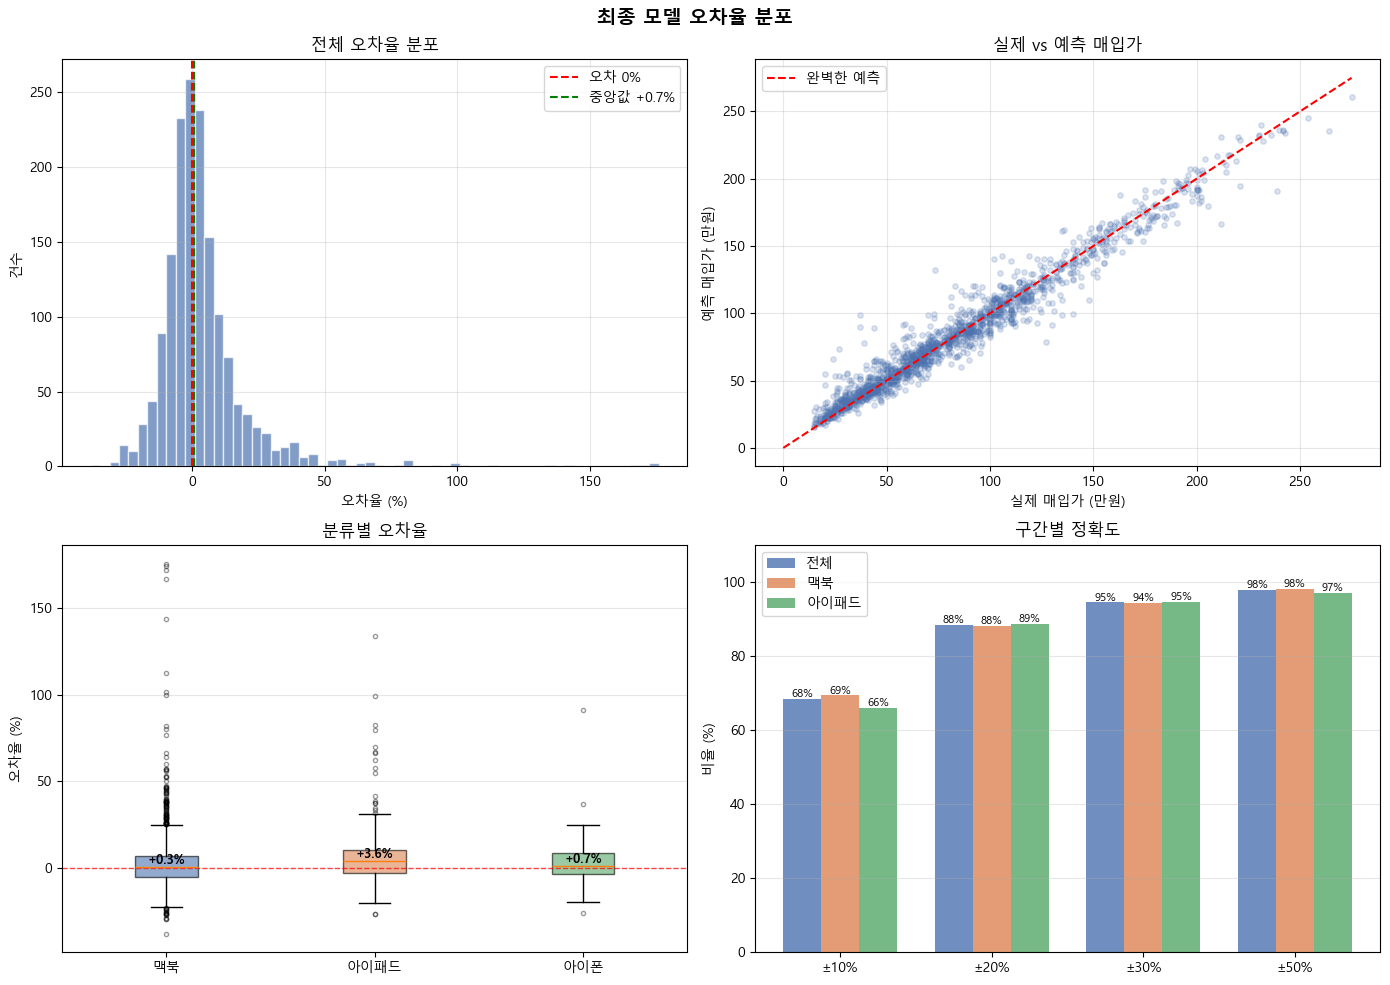

저장 완료: 오차율_분포_최종.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('최종 모델 오차율 분포', fontsize=14, fontweight='bold')

# (1) 오차율 히스토그램
ax = axes[0][0]
ax.hist(df['오차율'], bins=60, color='#4C72B0', alpha=0.7, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='오차 0%')
ax.axvline(df['오차율'].median(), color='green', linestyle='--',
           linewidth=1.5, label=f'중앙값 {df["오차율"].median():+.1f}%')
ax.set_title('전체 오차율 분포')
ax.set_xlabel('오차율 (%)')
ax.set_ylabel('건수')
ax.legend()
ax.grid(True, alpha=0.3)

# (2) 실제 vs 예측 산점도
ax = axes[0][1]
ax.scatter(df['매입가']/10000, df['최종예측가']/10000,
           alpha=0.2, s=15, color='#4C72B0')
max_val = max(df['매입가'].max(), df['최종예측가'].max()) / 10000
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='완벽한 예측')
ax.set_title('실제 vs 예측 매입가')
ax.set_xlabel('실제 매입가 (만원)')
ax.set_ylabel('예측 매입가 (만원)')
ax.legend()
ax.grid(True, alpha=0.3)

# (3) 분류별 박스플롯
ax = axes[1][0]
분류별 = [df[df['분류']==c]['오차율'].values for c in ['맥북','아이패드','아이폰']]
bp = ax.boxplot(분류별, labels=['맥북','아이패드','아이폰'], patch_artist=True,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, color in zip(bp['boxes'], ['#4C72B0','#DD8452','#55A868']):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
for i, cat in enumerate(['맥북','아이패드','아이폰']):
    med = df[df['분류']==cat]['오차율'].median()
    ax.text(i+1, med+2, f'{med:+.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_title('분류별 오차율')
ax.set_ylabel('오차율 (%)')
ax.grid(True, alpha=0.3, axis='y')

# (4) 구간별 정확도
ax = axes[1][1]
구간들 = ['±10%','±20%','±30%','±50%']
전체   = [(df['오차율_절대']<=v).mean()*100 for v in [10,20,30,50]]
맥북   = [(df[df['분류']=='맥북']['오차율_절대']<=v).mean()*100 for v in [10,20,30,50]]
아이패드 = [(df[df['분류']=='아이패드']['오차율_절대']<=v).mean()*100 for v in [10,20,30,50]]
x = range(len(구간들))
width = 0.25
b1 = ax.bar([i-width for i in x], 전체,    width, label='전체',    color='#4C72B0', alpha=0.8)
b2 = ax.bar(x,                    맥북,    width, label='맥북',    color='#DD8452', alpha=0.8)
b3 = ax.bar([i+width for i in x], 아이패드, width, label='아이패드', color='#55A868', alpha=0.8)
for bars, vals in [(b1,전체),(b2,맥북),(b3,아이패드)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.0f}%', ha='center', fontsize=8)
ax.set_title('구간별 정확도')
ax.set_xticks(list(x))
ax.set_xticklabels(구간들)
ax.set_ylabel('비율 (%)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig('오차율_분포_최종.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: 오차율_분포_최종.png')

---
## 11. 마진 분석 및 백테스팅

매입-판매 연결: 1043건 → 정제 후: 937건

=== 마진 분석 결과 ===
평균 마진율:   30.3%
중앙값 마진율: 33.9%
평균 마진액:   176,132원

=== 분류별 마진 ===
분류             건수        평균마진액      평균마진율      중앙마진율
----------------------------------------------------
맥북            676     183,837원      27.9%      32.7%
아이패드          236     154,678원      36.2%      35.7%
아이폰            25     170,320원      40.7%      37.9%

=== RFP 목표 달성률 ===
  손실(0%미만): 15.6%
  목표미달(0~15%): 7.5%
  목표범위(15~30%): 18.8%
  목표초과(30~50%): 42.4%
  고마진(50%+): 15.8%


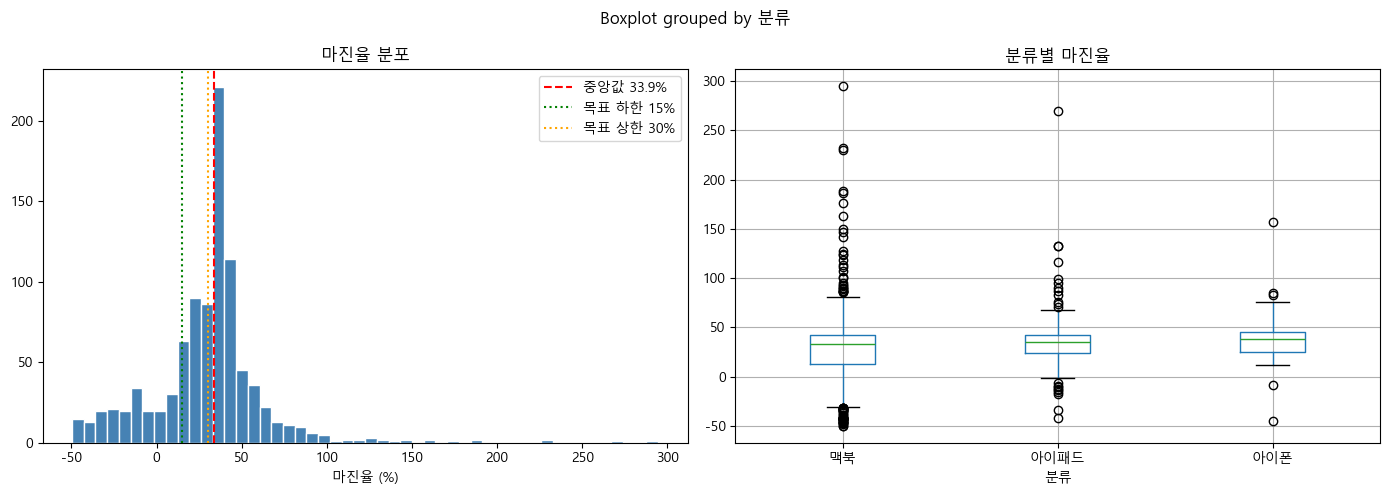

In [16]:
# 판매 데이터 로드 및 매입-판매 연결
df_sales = pd.read_csv(SALES_FILE, encoding='utf-8-sig')
df_sales['price'] = pd.to_numeric(
    df_sales['price'].astype(str).str.replace(',','').str.strip(), errors='coerce')
df_sales['stockId_clean'] = df_sales['stockId'].astype(str).str.split('.').str[0].str.strip()

# 매입 데이터 stockId
df_raw_id = pd.read_csv(STOCK_FILE, encoding='utf-8-sig')
df_raw_id['매입가'] = pd.to_numeric(
    df_raw_id['매입가'].astype(str).str.replace(',','').str.strip(), errors='coerce')
df_raw_id['출시가'] = pd.to_numeric(
    df_raw_id['출시가'].astype(str).str.replace(',','').str.strip(), errors='coerce')
df_raw_id['stockId_clean'] = df_raw_id['id'].astype(str).str.strip()

# 판매완료만 필터
df_sold = df_sales[df_sales['status'] == 'soldOut'].copy()

# 매입-판매 연결
df_margin = df_sold.merge(
    df_raw_id[['stockId_clean','매입가','출시가','분류','품명']],
    on='stockId_clean', how='inner')
df_margin['마진액'] = df_margin['price'] - df_margin['매입가']
df_margin['마진율'] = df_margin['마진액'] / df_margin['매입가'] * 100

# 이상치 정제 (분류별 최소 매입가 기준)
df_margin_clean = df_margin[
    ((df_margin['분류']=='맥북')    & (df_margin['매입가'] >= 200000)) |
    ((df_margin['분류']=='아이패드') & (df_margin['매입가'] >= 100000)) |
    ((df_margin['분류']=='아이폰')  & (df_margin['매입가'] >= 100000))
].copy()
df_margin_clean = df_margin_clean[df_margin_clean['마진율'] >= -50]

print(f"매입-판매 연결: {len(df_margin)}건 → 정제 후: {len(df_margin_clean)}건")
print(f"\n=== 마진 분석 결과 ===")
print(f"평균 마진율:   {df_margin_clean['마진율'].mean():.1f}%")
print(f"중앙값 마진율: {df_margin_clean['마진율'].median():.1f}%")
print(f"평균 마진액:   {df_margin_clean['마진액'].mean():,.0f}원")

print(f"\n=== 분류별 마진 ===")
print(f"{'분류':<10} {'건수':>6} {'평균마진액':>12} {'평균마진율':>10} {'중앙마진율':>10}")
print("-" * 52)
for cat in ['맥북','아이패드','아이폰']:
    sub = df_margin_clean[df_margin_clean['분류']==cat]
    if len(sub) == 0: continue
    print(f"{cat:<10} {len(sub):>6} {sub['마진액'].mean():>11,.0f}원 "
          f"{sub['마진율'].mean():>9.1f}% {sub['마진율'].median():>9.1f}%")

print(f"\n=== RFP 목표 달성률 ===")
for label, lo, hi in [
    ('손실(0%미만)',     -999,  0),
    ('목표미달(0~15%)',     0, 15),
    ('목표범위(15~30%)',   15, 30),
    ('목표초과(30~50%)',   30, 50),
    ('고마진(50%+)',       50, 999)
]:
    pct = ((df_margin_clean['마진율']>=lo)&(df_margin_clean['마진율']<hi)).mean()*100
    print(f"  {label}: {pct:.1f}%")

# 마진율 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_margin_clean['마진율'], bins=50,
             color='steelblue', edgecolor='white')
axes[0].axvline(x=df_margin_clean['마진율'].median(),
                color='red', linestyle='--',
                label=f"중앙값 {df_margin_clean['마진율'].median():.1f}%")
axes[0].axvline(x=15, color='green', linestyle=':', label='목표 하한 15%')
axes[0].axvline(x=30, color='orange', linestyle=':', label='목표 상한 30%')
axes[0].set_title('마진율 분포')
axes[0].set_xlabel('마진율 (%)')
axes[0].legend()

df_margin_clean.boxplot(column='마진율', by='분류', ax=axes[1])
axes[1].set_title('분류별 마진율')
plt.tight_layout()
plt.show()

In [19]:
# ── 조회할 품목 ID ──
stock_id = '21121547652547'   # ← 여기만 바꾸세요

row = df[df['id_str'] == str(stock_id)]
if len(row) == 0:
    print(f'❌ {stock_id} — 데이터에 없는 품목이에요.')
else:
    row = row.iloc[0]
    print(f'품명:   {row["품명"]}')
    print(f'분류:   {row["분류"]}')
    print(f'출시가: {row["출시가"]:,.0f}원')
    print(f'경과월: {row["Age_month"]:.0f}개월')
    print()

    결과 = 차감로직_계산(
        stock_id, row['xgb_기준가'], row['출시가'], row['분류'], verbose=True)

    실제매입가 = row['매입가']
    오차율 = (결과['최종예측가'] - 실제매입가) / 실제매입가 * 100
    print(f'\n실제 매입가:  {실제매입가:>16,.0f}원')
    print(f'오차:         {결과["최종예측가"]-실제매입가:>+16,.0f}원')
    print(f'오차율:       {오차율:>+16.1f}%')

품명:   맥북 프로 레티나 15인치 2018 터치바 스페이스그레이 고급형
분류:   맥북
출시가: 3,490,000원
경과월: 41개월

품목 ID: 21121547652547  |  분류: 맥북

① XGBoost 기준가: 1,016,019원 (잔존율 29.1%)

② 정률 차감:
   생활 기스 [약간]:       -9,551원  (-0.94%)
   찍힘/깨짐 [약간]:      -18,492원  (-1.82%)
   배터리 사이클 [50~100]:       -7,519원  (-0.74%)
   정률 합계:            -35,561원

③ 정액 차감/추가:
   업그레이드 [RAM]:       50,000원  (RAM +50,000원)
   ── 담당자 문의 ──
   ⚠️  작동이상: 트랙패드 이상(담당자 문의) → 담당자 문의
   정액 합계:             50,000원

④ 최종 예측 매입가:
   기준가:             1,016,019원
   + 정률 차감:          -35,561원
   + 정액 조정:           50,000원
   = 최종 예측:        1,030,458원

실제 매입가:         1,020,000원
오차:                  +10,458원
오차율:                   +1.0%


In [20]:
# 손실 케이스 상세 분석
df_loss = df_margin_clean[df_margin_clean['마진율'] < 0].copy()
df_loss = df_loss.sort_values('마진율')

print(f"=== 손실 케이스 분석 ({len(df_loss)}건) ===")
print(f"\n마진율 분포:")
print(f"  -10% 이상:   {(df_loss['마진율']>=-10).sum()}건  (소폭 손실)")
print(f"  -10~-30%:   {((df_loss['마진율']>=-30)&(df_loss['마진율']<-10)).sum()}건")
print(f"  -30~-50%:   {((df_loss['마진율']>=-50)&(df_loss['마진율']<-30)).sum()}건")
print(f"  -50% 미만:   {(df_loss['마진율']<-50).sum()}건  (심각한 손실 → 휴먼에러 의심)")

print(f"\n=== 심각한 손실 케이스 (-30% 미만) ===")
severe = df_loss[df_loss['마진율'] < -30].sort_values('마진율')
print(severe[['품명','분류','매입가','price','마진율','마진액']].to_string())

print(f"\n=== 소폭 손실 케이스 (-10% 이상) ===")
minor = df_loss[df_loss['마진율'] >= -10]
print(f"건수: {len(minor)}건")
print(f"평균 마진율: {minor['마진율'].mean():.1f}%")
print(f"→ 이건 정상 범위일 수 있어 (운영 비용 등)")

=== 손실 케이스 분석 (146건) ===

마진율 분포:
  -10% 이상:   32건  (소폭 손실)
  -10~-30%:   69건
  -30~-50%:   45건
  -50% 미만:   0건  (심각한 손실 → 휴먼에러 의심)

=== 심각한 손실 케이스 (-30% 미만) ===
                                             품명    분류      매입가    price        마진율      마진액
478         맥북 프로 레티나 16인치 2019 터치바 스페이스그레이 중급형    맥북  1530000   770000 -49.673203  -760000
150         맥북 프로 레티나 16인치 2019 터치바 스페이스그레이 고급형    맥북  1090000   550000 -49.541284  -540000
896         맥북 프로 레티나 13인치 2019 터치바 스페이스그레이 중급형    맥북   480000   250000 -47.916667  -230000
688         맥북 프로 레티나 15인치 2019 터치바 스페이스그레이 고급형    맥북   680000   360000 -47.058824  -320000
908              맥북 프로 레티나 13인치 2020 터치바 실버 기본형    맥북   660000   350000 -46.969697  -310000
427         맥북 프로 레티나 16인치 2019 터치바 스페이스그레이 중급형    맥북  1830000   980000 -46.448087  -850000
138                      맥북 에어 13인치 2019 고급형 골드    맥북   530000   285000 -46.226415  -245000
71          맥북 프로 레티나 15인치 2019 터치바 스페이스그레이 중급형    맥북   700000   380000 -45.714286  -320000
564       

In [21]:
# 동일 품명 내 매입가 분포 확인
print("=== 손실 케이스 품명별 분석 ===")

df_loss_severe = df_margin_clean[df_margin_clean['마진율'] < -30].copy()

for 품명 in df_loss_severe['품명'].value_counts().head(5).index:
    # 전체 데이터에서 해당 품명
    전체 = df_margin_clean[df_margin_clean['품명']==품명]
    손실 = df_loss_severe[df_loss_severe['품명']==품명]
    
    print(f"\n[{품명[:30]}]")
    print(f"  전체 {len(전체)}건 | 손실 {len(손실)}건")
    print(f"  전체 매입가: 중앙 {전체['매입가'].median():,.0f}원  "
          f"범위 {전체['매입가'].min():,}~{전체['매입가'].max():,}원")
    print(f"  손실 매입가: {손실['매입가'].values}")
    print(f"  손실 판매가: {손실['price'].values}")
    print(f"  정상 판매가 중앙: {전체['price'].median():,.0f}원")
    print(f"  → 판매가 정상? {손실['price'].median():,.0f}원 vs "
          f"전체중앙 {전체['price'].median():,.0f}원")

=== 손실 케이스 품명별 분석 ===

[맥북 프로 레티나 16인치 2019 터치바 스페이스그레]
  전체 18건 | 손실 7건
  전체 매입가: 중앙 1,150,000원  범위 510,000~1,870,000원
  손실 매입가: [1510000 1830000 1530000 1520000 1590000 1350000  950000]
  손실 판매가: [870000 980000 770000 870000 980000 940000 650000]
  정상 판매가 중앙: 891,000원
  → 판매가 정상? 870,000원 vs 전체중앙 891,000원

[맥북 프로 레티나 15인치 Mid-2017 터치바 스페]
  전체 10건 | 손실 3건
  전체 매입가: 중앙 905,000원  범위 200,000~1,600,000원
  손실 매입가: [ 910000  720000 1470000]
  손실 판매가: [ 580000  500000 1000000]
  정상 판매가 중앙: 795,000원
  → 판매가 정상? 580,000원 vs 전체중앙 795,000원

[맥북 프로 레티나 15인치 2019 터치바 스페이스그레]
  전체 10건 | 손실 2건
  전체 매입가: 중앙 862,500원  범위 370,000~2,150,000원
  손실 매입가: [668000 680000]
  손실 판매가: [390000 360000]
  정상 판매가 중앙: 922,500원
  → 판매가 정상? 375,000원 vs 전체중앙 922,500원

[맥북 프로 레티나 15인치 2019 터치바 스페이스그레]
  전체 6건 | 손실 2건
  전체 매입가: 중앙 1,085,000원  범위 550,000~1,550,000원
  손실 매입가: [700000 940000]
  손실 판매가: [380000 530000]
  정상 판매가 중앙: 1,114,500원
  → 판매가 정상? 455,000원 vs 전체중앙 1,114,500원

[맥북 프로 레티나 15인치 2018 터치바 스페이스그레]
  전체 23건

In [22]:
# 동일 품명 판매가 중앙값 대비
# 50% 미만 or 200% 초과 케이스 제거

df_margin_clean2 = df_margin_clean.copy()

# 품명별 판매가 중앙값 계산
판매가_중앙 = df_margin_clean2.groupby('품명')['price'].median()
df_margin_clean2['판매가_중앙'] = df_margin_clean2['품명'].map(판매가_중앙)
df_margin_clean2['판매가_비율'] = (
    df_margin_clean2['price'] / df_margin_clean2['판매가_중앙'])

# 비정상 제거
before = len(df_margin_clean2)
df_margin_clean3 = df_margin_clean2[
    df_margin_clean2['판매가_비율'].between(0.5, 2.0)
].copy()

print(f"정제 전: {before}건")
print(f"정제 후: {len(df_margin_clean3)}건")
print(f"제거:    {before - len(df_margin_clean3)}건")

print(f"\n=== 정제 후 마진율 ===")
print(f"평균:   {df_margin_clean3['마진율'].mean():.1f}%")
print(f"중앙값: {df_margin_clean3['마진율'].median():.1f}%")

for label, lo, hi in [
    ('손실(0%미만)',    -999,  0),
    ('목표미달(0~15%)',    0, 15),
    ('목표범위(15~30%)',  15, 30),
    ('목표초과(30~50%)',  30, 50),
    ('고마진(50%+)',      50, 999),
]:
    pct = ((df_margin_clean3['마진율']>=lo) &
            (df_margin_clean3['마진율']<hi)).mean()*100
    print(f"  {label}: {pct:.1f}%")

정제 전: 937건
정제 후: 851건
제거:    86건

=== 정제 후 마진율 ===
평균:   31.9%
중앙값: 34.2%
  손실(0%미만): 13.2%
  목표미달(0~15%): 8.1%
  목표범위(15~30%): 18.8%
  목표초과(30~50%): 44.2%
  고마진(50%+): 15.7%


In [23]:
# 매입가도 품명별 중앙값 대비 비정상 제거

df_margin_clean4 = df_margin_clean3.copy()

# 품명별 매입가 중앙값
매입가_중앙 = df_margin_clean4.groupby('품명')['매입가'].median()
df_margin_clean4['매입가_중앙'] = df_margin_clean4['품명'].map(매입가_중앙)
df_margin_clean4['매입가_비율'] = (
    df_margin_clean4['매입가'] / df_margin_clean4['매입가_중앙'])

# 비정상 매입가 확인
print("=== 매입가 비율 분포 ===")
print(f"0.3 미만 (너무 싸게 매입): "
      f"{(df_margin_clean4['매입가_비율']<0.3).sum()}건")
print(f"0.3~0.5:                  "
      f"{((df_margin_clean4['매입가_비율']>=0.3)&(df_margin_clean4['매입가_비율']<0.5)).sum()}건")
print(f"0.5~2.0 (정상):           "
      f"{df_margin_clean4['매입가_비율'].between(0.5,2.0).sum()}건")
print(f"2.0 초과 (너무 비싸게 매입): "
      f"{(df_margin_clean4['매입가_비율']>2.0).sum()}건")

# 비정상 매입가 샘플
print(f"\n=== 매입가 2배 초과 케이스 ===")
over = df_margin_clean4[df_margin_clean4['매입가_비율']>2.0].sort_values(
    '매입가_비율', ascending=False)
print(over[['품명','매입가','매입가_중앙','매입가_비율',
            'price','마진율']].head(10).to_string())

# 정제
before = len(df_margin_clean4)
df_margin_final = df_margin_clean4[
    df_margin_clean4['매입가_비율'].between(0.3, 2.5)
].copy()

print(f"\n=== 최종 정제 결과 ===")
print(f"정제 전: {before}건")
print(f"정제 후: {len(df_margin_final)}건")
print(f"제거:    {before - len(df_margin_final)}건")

print(f"\n{'':20} {'원본(937건)':>12} {'최종정제':>12}")
print("-" * 46)
print(f"{'평균마진율':20} {'30.3%':>12} "
      f"{df_margin_final['마진율'].mean():>11.1f}%")
print(f"{'중앙값마진율':20} {'33.9%':>12} "
      f"{df_margin_final['마진율'].median():>11.1f}%")

for label, lo, hi in [
    ('손실(0%미만)',    -999,  0),
    ('목표미달(0~15%)',    0, 15),
    ('목표범위(15~30%)',  15, 30),
    ('목표초과(30~50%)',  30, 50),
    ('고마진(50%+)',      50, 999),
]:
    원본 = ((df_margin_clean['마진율']>=lo) &
             (df_margin_clean['마진율']<hi)).mean()*100
    정제 = ((df_margin_final['마진율']>=lo) &
             (df_margin_final['마진율']<hi)).mean()*100
    print(f"  {label:<18} {원본:>11.1f}% {정제:>11.1f}%")

=== 매입가 비율 분포 ===
0.3 미만 (너무 싸게 매입): 2건
0.3~0.5:                  23건
0.5~2.0 (정상):           817건
2.0 초과 (너무 비싸게 매입): 9건

=== 매입가 2배 초과 케이스 ===
                                            품명      매입가    매입가_중앙    매입가_비율    price        마진율
214   맥북 프로 레티나 13인치 Mid-2017 논터치바 스페이스그레이 중급형  1040000  360000.0  2.888889   900000 -13.461538
516   맥북 프로 레티나 13인치 Mid-2017 논터치바 스페이스그레이 중급형  1025000  360000.0  2.847222  1280000  24.878049
87    맥북 프로 레티나 13인치 Late-2016 터치바 스페이스그레이 고급형  1110000  410000.0  2.707317   819000 -26.216216
1003  맥북 프로 레티나 13인치 Mid-2017 논터치바 스페이스그레이 중급형   970000  360000.0  2.694444   860000 -11.340206
777        맥북 프로 레티나 13인치 2018 터치바 스페이스그레이 중급형  1255000  500000.0  2.510000   730000 -41.832669
114        맥북 프로 레티나 13인치 Late-2016 터치바 실버 고급형  1180000  500000.0  2.360000   810000 -31.355932
281                맥북 프로 레티나 15인치 Mid-2015 고급형  1190000  550000.0  2.163636  1420000  19.327731
41                 맥북 프로 레티나 15인치 Mid-2015 고급형  1140000  550000.0  2.072727  1600000  4

---
## 12. 모델 저장

In [ ]:
# 최종 모델 및 로직 저장
joblib.dump(model,    'model_최종.pkl')
joblib.dump(le_cat,   'encoder_분류.pkl')
joblib.dump(le_brand, 'encoder_품명.pkl')

with open('정률표_최종.json', 'w', encoding='utf-8') as f:
    json.dump(정률표, f, ensure_ascii=False, indent=2)

with open('정액표_맥북.json', 'w', encoding='utf-8') as f:
    json.dump(정액표_맥북, f, ensure_ascii=False, indent=2)

print("✅ 저장 완료!")
print("   - model_최종.pkl      : XGBoost 예측 모델")
print("   - encoder_분류.pkl    : 분류 인코더")
print("   - encoder_품명.pkl    : 품명 인코더")
print("   - 정률표_최종.json    : 정률 차감 로직")
print("   - 정액표_맥북.json    : 정액 차감 로직")

---
## 수정 가이드

**정률 수치 변경:** 섹션 6 `정률표` 수정 → 섹션 7 → 섹션 8~10 재실행

**정액 기준 변경:** 섹션 6 `정액표_맥북/아이패드/아이폰` 수정 → 섹션 7 → 재실행

**전처리 변경:** 섹션 2 수정 → 전체 재실행

### 찍힘/깨짐 분리 (데이터 충분해진 후)
```python
# 섹션 6에서 수정
정률표['찍힘'] = {'없음': 0.0, '약간': -0.02, '심각': -0.05}
정률표['깨짐'] = {'없음': 0.0, '약간': -0.05}
del 정률표['찍힘/깨짐']
```